In [1]:
from pybaseball import  playerid_lookup
from pybaseball import  statcast_pitcher
from pybaseball import  statcast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#This function finds id info for any player in baseball history. I'll choose one of the more popular and successful pitchers in recent years Logan Webb for my first example
a = playerid_lookup('webb', 'logan')

# If there were multiple players for one name, we could filter by year and/or team. 
a[a['mlb_played_first'] > 2000.0]

,name_last,name_first,key_mlbam,key_retro,key_bbref,key_fangraphs,mlb_played_first,mlb_played_last
0,webb,logan,657277,webbl001,webblo01,17995,2019.0,2025.0


In [4]:
#This data is on a pitch level. This df contains all 3000+ pitches thrown by Webb in the designated timeframe.
df = statcast_pitcher('2025-04-01', '2025-09-30', 657277)
df.head()

Gathering Player Data


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,FC,2025-09-28,91.0,-1.59,5.01,"Webb, Logan",678662,657277,field_out,hit_into_play,...,NaN,2.19,0.14,0.14,25.5,6.391003,4.606985,36.210130,27.653712,27.584027
1,ST,2025-09-28,85.7,-1.81,4.86,"Webb, Logan",678662,657277,NaN,ball,...,NaN,3.09,-1.58,-1.58,18.6,NaN,NaN,NaN,NaN,NaN
2,FF,2025-09-28,94.0,-1.41,5.15,"Webb, Logan",678662,657277,NaN,ball,...,NaN,1.47,0.65,0.65,28.2,NaN,NaN,NaN,NaN,NaN
3,FC,2025-09-28,90.3,-1.56,5.16,"Webb, Logan",678662,657277,NaN,swinging_strike,...,NaN,2.05,-0.02,-0.02,24.8,9.922417,15.446748,26.804287,36.033673,22.010802
4,FF,2025-09-28,94.5,-1.41,5.06,"Webb, Logan",690022,657277,field_out,hit_into_play,...,NaN,1.91,0.86,0.86,21.7,NaN,NaN,NaN,NaN,NaN


In [2]:
df = statcast_pitcher('2025-04-01', '2025-04-03')

ValueError: Player ID is required. If you need to find a player's id, try pybaseball.playerid_lookup(last_name, first_name) and use their key_mlbam. If you want statcast data for all players, try the statcast() function.

In [5]:
df['pitch_type'].value_counts() / len(df)


pitch_type
SI    0.333645
ST    0.267166
CH    0.244070
FF    0.078340
FC    0.076779
Name: count, dtype: float64

Most of these columns are describing something taking place after the pitch has been thrown (i.e. exit velocity, location, spin). Some of these situational game factors will be useful, but some lag features will need to be added. My hypothesis is that the previous sequence of pitches correlates highly to pitch choice in a given moment

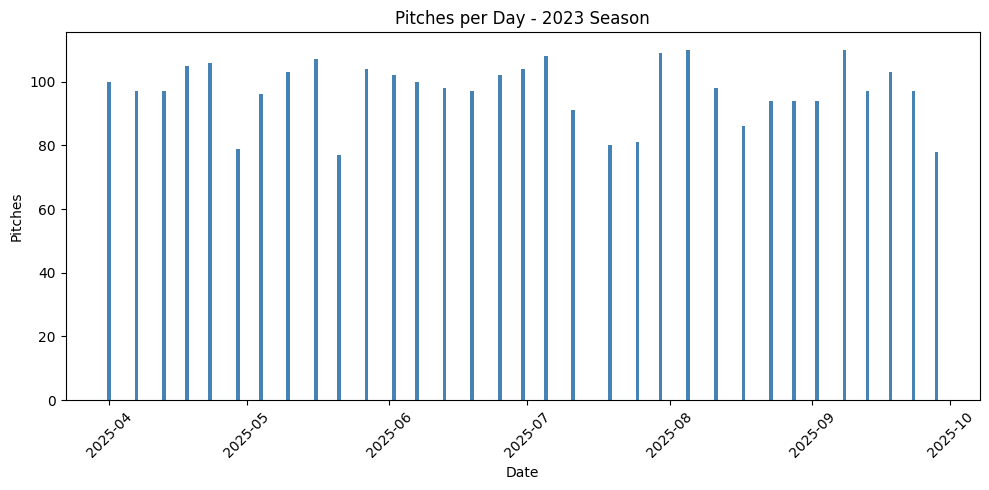

In [6]:
df["game_date"] = pd.to_datetime(df["game_date"])
counts = df.groupby(df["game_date"].dt.date).size()
plt.figure(figsize=(10, 5))
plt.bar(counts.index, counts.values, color="steelblue")

plt.xlabel("Date")
plt.ylabel("Pitches")
plt.title("Pitches per Day - 2023 Season")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [13]:
missing = df.isna().sum().reset_index()
missing

,index,0
0,pitch_type,2
1,game_date,0
2,release_speed,2
3,release_pos_x,2
4,release_pos_z,2
...,...,...
113,attack_angle,2471
114,attack_direction,2471
115,swing_path_tilt,2471
116,intercept_ball_minus_batter_pos_x_inches,2471


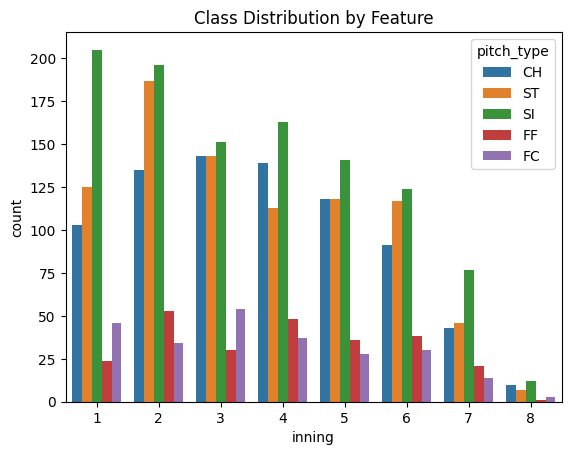

In [7]:
sns.countplot(data=df, x='inning', hue='pitch_type')
plt.title('Class Distribution by Feature')
plt.show()

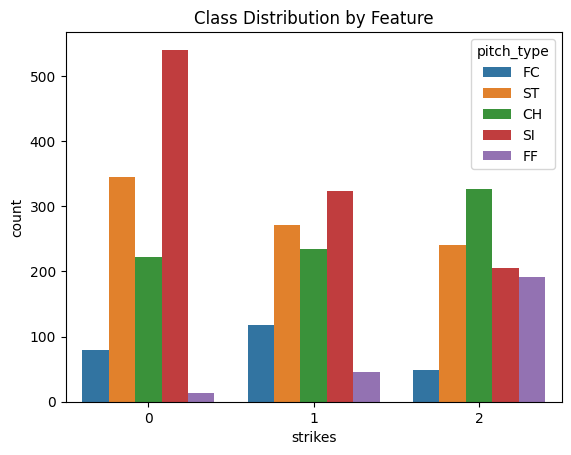

In [8]:
sns.countplot(data=df, x='strikes', hue='pitch_type')
plt.title('Class Distribution by Feature')
plt.show()

In [17]:
df[['pitch_type', 'pitch_name']].value_counts()
# {'FF':0, 'FA':0,
#               'FT':1, 'SI':1,
#               'FC':2,
#               'CU':3,'KC':3,'CS':3,'EP':3,
#               'SL':4,
#               'CH':5,'FS':5,'FO':5,'SC':5,
#               'KN':6,
#               'PO':np.nan}

# {0: ' Fastball',
# 1: 'Sinker',
# 2: 'Cutter',
# 3: 'Curveball',
# 4: 'Slider',
# 5: 'Changeup',
# 6: 'Knuckle'}


pitch_type  pitch_name     
CH          Changeup           1292
SI          Sinker             1020
ST          Sweeper             655
FF          4-Seam Fastball     123
Name: count, dtype: int64

In [29]:
#df[['game_pk', 'at_bat_number', 'pitch_number']].head(10)

a = df.groupby(['game_pk', 'at_bat_number'])['pitch_number'].max().reset_index()

print('Average length of at-bat: Logan Webb')
a['pitch_number'].mean()

Average length of at-bat: Logan Webb


np.float64(3.7433414043583535)

In [ ]:
df['game_pk'] = df['game_pk'].astype(str)
df['at_bat_number'] = df['at_bat_number'].astype(str)

# Concatenate again
df['pa_id'] = df['game_pk'] + "-" +df['at_bat_number']


In [34]:

missing = df.isna().sum().reset_index()
missing = missing.loc[missing[0] > 0]
missing

missing_list = missing['index'].to_list()


#These conatin player id's for whoever is on base. I'll replace with binary variables


#new dataframe with null columns removed
df2 = df.drop(missing_list, axis=1)
df2.columns



Index(['game_date', 'player_name', 'batter', 'pitcher', 'description', 'des',
       'game_type', 'stand', 'p_throws', 'home_team', 'away_team', 'type',
       'balls', 'strikes', 'game_year', 'outs_when_up', 'inning',
       'inning_topbot', 'game_pk', 'fielder_2', 'fielder_3', 'fielder_4',
       'fielder_5', 'fielder_6', 'fielder_7', 'fielder_8', 'fielder_9',
       'at_bat_number', 'pitch_number', 'home_score', 'away_score',
       'bat_score', 'fld_score', 'post_away_score', 'post_home_score',
       'post_bat_score', 'post_fld_score', 'delta_home_win_exp',
       'home_score_diff', 'bat_score_diff', 'home_win_exp', 'bat_win_exp',
       'age_pit_legacy', 'age_bat_legacy', 'age_pit', 'age_bat',
       'n_thruorder_pitcher', 'n_priorpa_thisgame_player_at_bat',
       'pitcher_days_since_prev_game', 'batter_days_until_next_game', 'pa_id'],
      dtype='str')

In [ ]:


df = df.sort_values(by=['game_pk', 'at_bat_number', 'pitch_number'])
df['pitch_id'] = df['game_pk'].astype(str) + "-" + df['at_bat_number'].astype(str) + "-" + df['pitch_number'].astype(str)
# df['pa_id'] = str(df['game_pk']) + "-" + str(df['at_bat_number'])
# df['pitch_id'] = str(df['pa_id']) + "-" + str(df['pitch_number'])
df['pitch_type_map'] = df['pitch_type'].map(pitch_dict)
fastball_maps = [0, 1]
df['is_fastball'] = np.where(df['pitch_type_map'].isin(fastball_maps), 1, 0)
#dropping rows with Nan

df = df.dropna(subset=['pitch_type_map'])
df['pitch_type_map'] = df['pitch_type_map'].astype(int)
df.dropna(subset=['pitch_type_map'], inplace = True)


#add lag pitches
df['prev_pitch_1'] = df['pitch_type_map'].shift(1)
df['prev_pitch_2'] = df['pitch_type_map'].shift(2)
df['prev_pitch_3'] = df['pitch_type_map'].shift(3)

df['on_1b'] = df['on_1b'] .fillna(0)
df['on_2b'] = df['on_2b'] .fillna(0)
df['on_3b'] = df['on_3b'] .fillna(0)

df['runners_on_base'] = df['on_1b'] + df['on_2b'] + df['on_3b']

df['runners_on_base'].value_counts()
df['runners_on_base'] = np.where(df['runners_on_base'] > 0.0001, 1, 0)



#current_pitch = row['pitch_id']
        
df["fb_prop_last_10"] = (
    df["is_fastball"]
    .shift(1)               
    .rolling(15, min_periods=1)
    .mean()
    )


In [ ]:
Plot out pitch types on: 
